<a href="https://colab.research.google.com/github/gon-1411/phantichdulieuhocsau/blob/main/H%C3%80_NGUY%E1%BB%84N_%C4%90%C4%82NG_KHOA_2474802010191_LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HÀ NGUYỄN ĐĂNG KHOA_LAB4

# LAB 4: BÀI THỰC HÀNH CHUẨN BỊ DỮ LIỆU
## Titanic Disaster – Data Preparation & EDA

**Mô tả dữ liệu:**  
Vụ chìm tàu Titanic là một trong những vụ đắm tàu khét tiếng nhất trong lịch sử. Ngày 15/4/1912, con tàu "không thể đắm" RMS Titanic đã đâm vào tảng băng và chìm trong chuyến đầu tiên. Có 1502 trong số 2224 hành khách và thủy thủ đoàn thiệt mạng.

**Yêu cầu:** Chuẩn bị dữ liệu để xây dựng mô hình dự báo nhóm hành khách có khả năng sống sót.

| Variable | Definition | Key |
|---|---|---|
| PassengerId | Identifier | |
| Survived | Survival | 0=No, 1=Yes |
| Pclass | Ticket class | 1=1st, 2=2nd, 3=3rd |
| Name | Passenger name | |
| Sex | Sex | |
| Age | Age in years | |
| SibSp | # siblings/spouses aboard | |
| Parch | # parents/children aboard | |
| Ticket | Ticket number | |
| Fare | Passenger fare | |
| Cabin | Cabin number | |
| Embarked | Port of Embarkation | C=Cherbourg, Q=Queenstown, S=Southampton |

##  Cài đặt thư viện

In [1]:
# Cài đặt thư viện cần thiết
!pip install missingno -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import missingno as msno
import warnings
warnings.filterwarnings('ignore')

# Cấu hình hiển thị
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')
sns.set_palette('Set2')

print(' Thư viện đã được import thành công!')

 Thư viện đã được import thành công!


---
# PHẦN 1: DATA CLEANSING & FEATURE ENGINEERING

## Bước 1: Load dữ liệu

In [4]:
# ============================================================
# Bước 1: Viết hàm load_data() để tải dữ liệu
# ============================================================

def load_data(filepath):
    """
    Tải dữ liệu từ file CSV vào DataFrame.

    Args:
        filepath (str): Đường dẫn đến file CSV
    Returns:
        pd.DataFrame: DataFrame chứa dữ liệu
    """
    df = pd.read_csv(filepath)
    return df

# Tải dữ liệu
# Nếu chạy trên Google Colab, upload file trước hoặc mount Google Drive
# from google.colab import files
# uploaded = files.upload()  # Upload titanic_disaster.csv

# Hoặc mount Google Drive:
# from google.colab import drive
# drive.mount('/content/drive')
# df = load_data('/content/drive/MyDrive/titanic_disaster.csv')

# Tải trực tiếp (đặt file cùng thư mục với notebook)
df = load_data('titanic_disaster.csv')

print('='*60)
print(f' Dataset shape: {df.shape[0]} hàng x {df.shape[1]} cột')
print('='*60)
print('\n 10 dòng đầu tiên:')
df.head(10)

 Dataset shape: 891 hàng x 12 cột

 10 dòng đầu tiên:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [5]:
# Thông tin tổng quan về dataset
print(' Thông tin Dataset:')
print('-'*50)
df.info()

 Thông tin Dataset:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Thống kê mô tả
print(' Thống kê mô tả:')
df.describe(include='all')

 Thống kê mô tả:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


## Bước 2: Thống kê & Trực quan hóa dữ liệu thiếu

In [7]:
# ============================================================
# Bước 2: Thống kê dữ liệu thiếu và trực quan hóa bằng Heatmap
# ============================================================

# Tính số lượng và tỉ lệ dữ liệu thiếu
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().sum() / len(df) * 100).round(2)

missing_df = pd.DataFrame({
    'Số lượng thiếu': missing_count,
    'Tỉ lệ thiếu (%)': missing_pct
}).sort_values('Tỉ lệ thiếu (%)', ascending=False)

print(' Bảng thống kê dữ liệu thiếu:')
print('='*45)
print(missing_df[missing_df['Số lượng thiếu'] > 0].to_string())
print('='*45)

 Bảng thống kê dữ liệu thiếu:
          Số lượng thiếu  Tỉ lệ thiếu (%)
Cabin                687            77.10
Age                  177            19.87
Embarked               2             0.22


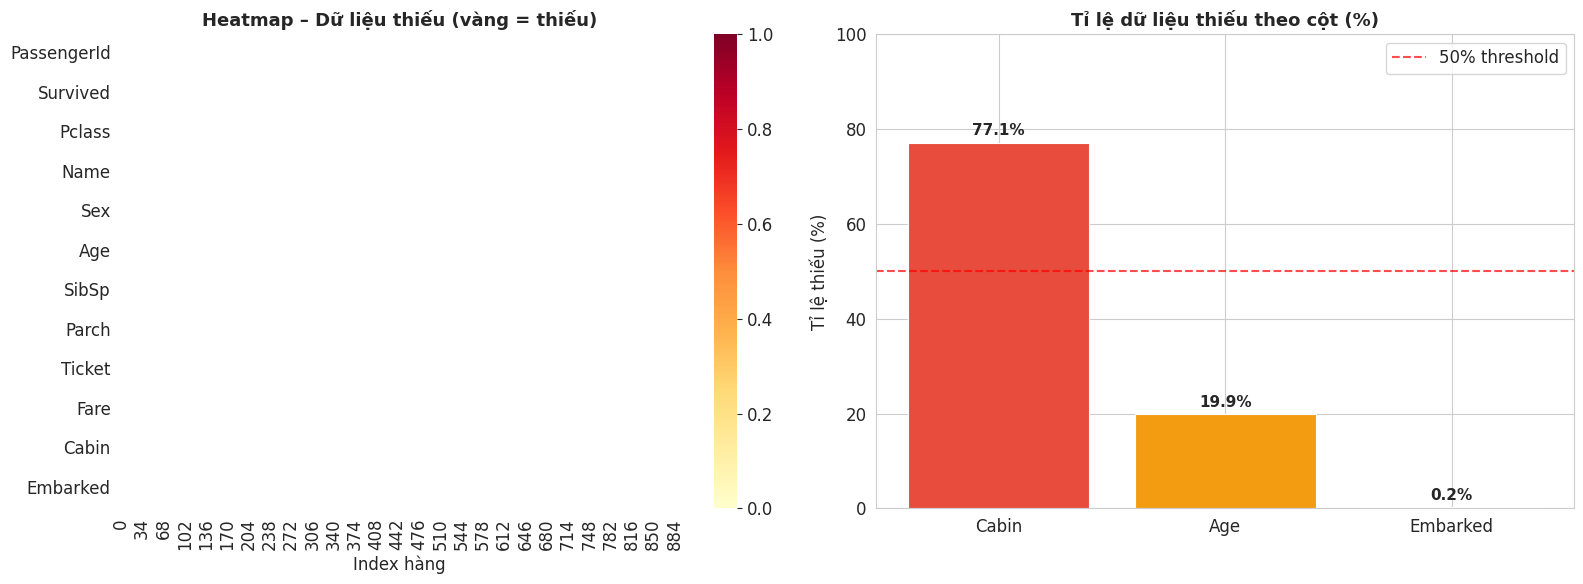


 NHẬN XÉT về tình trạng dữ liệu thiếu:
─────────────────────────────────────────────
• Age    : Thiếu 177 giá trị (~19.9%) → Cần xử lý bằng giá trị trung bình theo nhóm Pclass
• Cabin  : Thiếu 687 giá trị (~77.1%) → Tỉ lệ thiếu rất cao, không thể dùng trực tiếp,
           chỉ trích xuất ký tự đầu (loại cabin), còn lại điền 'Unknown'
• Embarked: Thiếu 2 giá trị (~0.2%)  → Ít, có thể điền bằng mode hoặc 'S' (phổ biến nhất)



In [8]:
# Trực quan hóa dữ liệu thiếu bằng Heatmap
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap dữ liệu thiếu
ax1 = axes[0]
missing_matrix = df.isnull().astype(int)
sns.heatmap(
    missing_matrix.T,
    ax=ax1,
    cbar=True,
    yticklabels=True,
    cmap='YlOrRd',
    linewidths=0.1
)
ax1.set_title('Heatmap – Dữ liệu thiếu (vàng = thiếu)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Index hàng')

# Bar chart tỉ lệ thiếu
ax2 = axes[1]
missing_only = missing_pct[missing_pct > 0].sort_values(ascending=False)
colors = ['#e74c3c' if v > 50 else '#f39c12' if v > 10 else '#3498db' for v in missing_only]
bars = ax2.bar(missing_only.index, missing_only.values, color=colors, edgecolor='white', linewidth=0.8)
ax2.set_title('Tỉ lệ dữ liệu thiếu theo cột (%)', fontsize=13, fontweight='bold')
ax2.set_ylabel('Tỉ lệ thiếu (%)')
ax2.set_ylim(0, 100)
for bar, val in zip(bars, missing_only.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50% threshold')
ax2.legend()

plt.tight_layout()
plt.savefig('missing_data_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("""
 NHẬN XÉT về tình trạng dữ liệu thiếu:
─────────────────────────────────────────────
• Age    : Thiếu 177 giá trị (~19.9%) → Cần xử lý bằng giá trị trung bình theo nhóm Pclass
• Cabin  : Thiếu 687 giá trị (~77.1%) → Tỉ lệ thiếu rất cao, không thể dùng trực tiếp,
           chỉ trích xuất ký tự đầu (loại cabin), còn lại điền 'Unknown'
• Embarked: Thiếu 2 giá trị (~0.2%)  → Ít, có thể điền bằng mode hoặc 'S' (phổ biến nhất)
""")

## Bước 3: Xử lý cột Name → firstName & secondName

In [9]:
# ============================================================
# Bước 3: Tách cột Name thành firstName và secondName
# ============================================================

print('Ví dụ Name gốc:')
print(df['Name'].head(5).to_string())

# Name có dạng: "Braund, Mr. Owen Harris"
# → secondName = phần trước dấu phẩy (họ)
# → firstName   = phần sau dấu phẩy (tên + danh xưng)
df[['secondName', 'firstName']] = df['Name'].str.split(',', n=1, expand=True)
df['secondName'] = df['secondName'].str.strip()
df['firstName']  = df['firstName'].str.strip()

# Xóa cột Name gốc
df.drop(columns=['Name'], inplace=True)

print('\n Sau khi tách:')
print(df[['secondName', 'firstName']].head(8).to_string())

Ví dụ Name gốc:
0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry

 Sau khi tách:
  secondName                                   firstName
0     Braund                             Mr. Owen Harris
1    Cumings  Mrs. John Bradley (Florence Briggs Thayer)
2  Heikkinen                                 Miss. Laina
3   Futrelle          Mrs. Jacques Heath (Lily May Peel)
4      Allen                           Mr. William Henry
5      Moran                                   Mr. James
6   McCarthy                               Mr. Timothy J
7    Palsson                       Master. Gosta Leonard


## Bước 4: Rút gọn cột Sex (male → M, female → F)

In [10]:
# ============================================================
# Bước 4: Thay thế male → M và female → F
# ============================================================

print('Trước khi thay thế:')
print(df['Sex'].value_counts().to_string())

df['Sex'] = df['Sex'].map({'male': 'M', 'female': 'F'})

print('\nSau khi thay thế:')
print(df['Sex'].value_counts().to_string())
print('\n Cột Sex đã được rút gọn thành công!')

Trước khi thay thế:
Sex
male      577
female    314

Sau khi thay thế:
Sex
M    577
F    314

 Cột Sex đã được rút gọn thành công!


## Bước 5: Xử lý dữ liệu thiếu cột Age

ValueError: The palette dictionary is missing keys: {'3', '2', '1'}

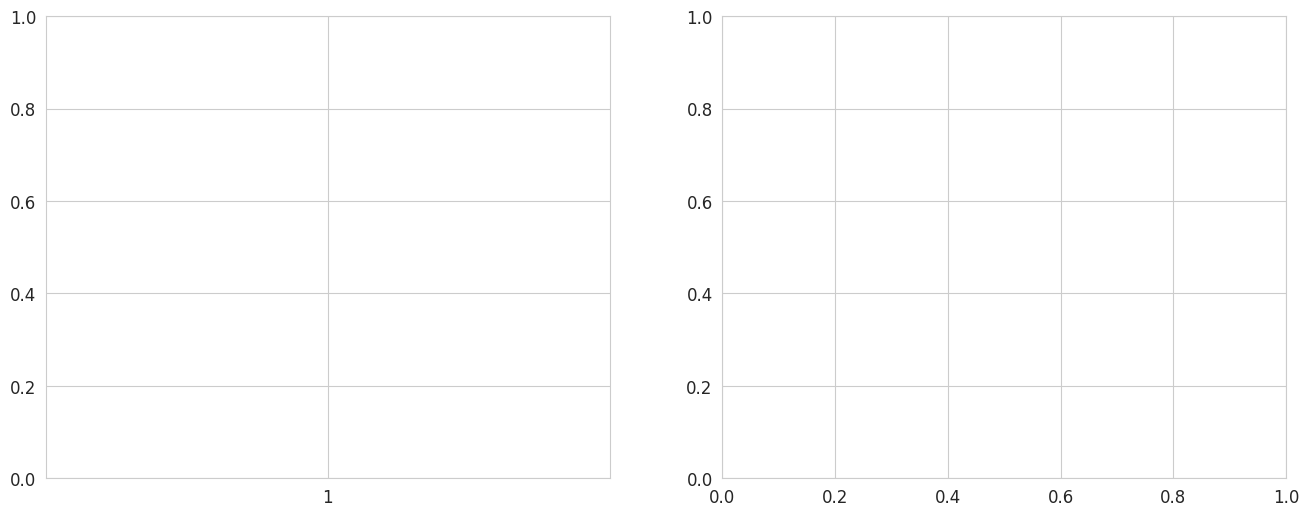

In [11]:
# ============================================================
# Bước 5a: Boxplot phân phối Age theo từng Pclass
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Age theo Pclass
ax1 = axes[0]
palette = {1: '#2ecc71', 2: '#3498db', 3: '#e74c3c'}
sns.boxplot(
    data=df.dropna(subset=['Age']),
    x='Pclass', y='Age',
    palette=palette,
    ax=ax1
)
ax1.set_title('Phân phối Tuổi theo Hạng vé (Pclass)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Hạng vé (1=1st, 2=2nd, 3=3rd)')
ax1.set_ylabel('Tuổi')

# Thêm giá trị trung bình
mean_ages = df.groupby('Pclass')['Age'].mean()
for pclass, mean_age in mean_ages.items():
    ax1.text(pclass - 1, mean_age + 1, f'Mean: {mean_age:.1f}',
             ha='center', fontsize=10, color='black', fontweight='bold')

# Violin plot bổ sung
ax2 = axes[1]
sns.violinplot(
    data=df.dropna(subset=['Age']),
    x='Pclass', y='Age',
    palette=palette,
    ax=ax2,
    inner='quartile'
)
ax2.set_title('Violin – Phân phối Tuổi theo Hạng vé', fontsize=13, fontweight='bold')
ax2.set_xlabel('Hạng vé (1=1st, 2=2nd, 3=3rd)')
ax2.set_ylabel('Tuổi')

plt.tight_layout()
plt.savefig('age_pclass_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# In thống kê tuổi theo nhóm
print('📊 Thống kê tuổi theo từng Pclass:')
print(df.groupby('Pclass')['Age'].describe().round(2).to_string())

print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Pclass 1 (hạng nhất): Tuổi trung bình ~38.2 tuổi – hành khách lớn tuổi nhất
• Pclass 2 (hạng hai) : Tuổi trung bình ~29.9 tuổi – trung bình
• Pclass 3 (hạng ba)  : Tuổi trung bình ~25.1 tuổi – trẻ tuổi nhất
→ Có sự khác biệt rõ rệt về tuổi giữa các hạng vé.
→ Quyết định: Thay thế Age thiếu bằng TRUNG BÌNH TUỔI THEO TỪNG NHÓM Pclass
  (chính xác hơn là dùng trung bình toàn bộ)
""")

In [12]:
# ============================================================
# Bước 5b: Thay thế Age thiếu bằng mean theo từng Pclass
# ============================================================

print(f'Số lượng Age bị thiếu TRƯỚC xử lý: {df["Age"].isnull().sum()}')

# Tính trung bình tuổi theo từng Pclass
age_mean_by_pclass = df.groupby('Pclass')['Age'].mean()
print('\nTuổi trung bình theo Pclass:')
print(age_mean_by_pclass.round(2).to_string())

# Thay thế dữ liệu thiếu
def fill_age(row):
    if pd.isnull(row['Age']):
        return age_mean_by_pclass[row['Pclass']]
    return row['Age']

df['Age'] = df.apply(fill_age, axis=1).round(1)

print(f'\nSố lượng Age bị thiếu SAU xử lý : {df["Age"].isnull().sum()}')
print(' Đã xử lý dữ liệu thiếu cho cột Age thành công!')

Số lượng Age bị thiếu TRƯỚC xử lý: 177

Tuổi trung bình theo Pclass:
Pclass
1    38.23
2    29.88
3    25.14

Số lượng Age bị thiếu SAU xử lý : 0
 Đã xử lý dữ liệu thiếu cho cột Age thành công!


In [ ]:
# Trực quan xác nhận kết quả sau xử lý Age
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap sau xử lý Age
ax1 = axes[0]
missing_after = df.isnull().astype(int)
sns.heatmap(missing_after.T, ax=ax1, cbar=True, cmap='YlOrRd',
            yticklabels=True, linewidths=0.1)
ax1.set_title('Heatmap dữ liệu thiếu (sau xử lý Age)', fontsize=13, fontweight='bold')

# Phân phối Age sau xử lý
ax2 = axes[1]
df['Age'].hist(bins=30, ax=ax2, color='#3498db', edgecolor='white', alpha=0.85)
ax2.set_title('Phân phối Age sau khi điền giá trị thiếu', fontsize=13, fontweight='bold')
ax2.set_xlabel('Tuổi')
ax2.set_ylabel('Số lượng')
ax2.axvline(df['Age'].mean(), color='red', linestyle='--', label=f'Mean: {df["Age"].mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.savefig('age_after_fill.png', dpi=150, bbox_inches='tight')
plt.show()

## Bước 6: Tạo biến Agegroup

 Biến Agegroup đã được tạo:
Agegroup
Adult    730
Teen      70
Kid       69
Older     22


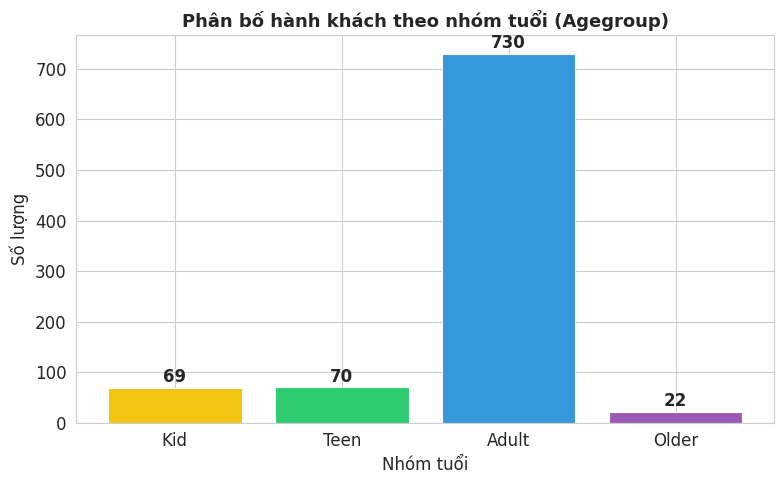

In [13]:
# ============================================================
# Bước 6: Tạo biến Agegroup
# (<=12]=Kid, (12,18]=Teen, (18,60]=Adult, (>60)=Older
# ============================================================

def assign_agegroup(age):
    if age <= 12:
        return 'Kid'
    elif age <= 18:
        return 'Teen'
    elif age <= 60:
        return 'Adult'
    else:
        return 'Older'

df['Agegroup'] = df['Age'].apply(assign_agegroup)

# Hoặc dùng pd.cut (cách ngắn gọn hơn)
# df['Agegroup'] = pd.cut(df['Age'],
#                         bins=[0, 12, 18, 60, 120],
#                         labels=['Kid', 'Teen', 'Adult', 'Older'],
#                         right=True)

print(' Biến Agegroup đã được tạo:')
print(df['Agegroup'].value_counts().to_string())

# Trực quan
fig, ax = plt.subplots(figsize=(8, 5))
order = ['Kid', 'Teen', 'Adult', 'Older']
colors = ['#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
counts = df['Agegroup'].value_counts()[order]
bars = ax.bar(order, counts.values, color=colors, edgecolor='white', linewidth=0.8)
ax.set_title('Phân bố hành khách theo nhóm tuổi (Agegroup)', fontsize=13, fontweight='bold')
ax.set_xlabel('Nhóm tuổi')
ax.set_ylabel('Số lượng')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('agegroup_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Bước 7: Trích xuất namePrefix (Mr, Mrs, Miss, Master)

In [14]:
# ============================================================
# Bước 7: Tách namePrefix từ firstName
# ============================================================

print('Ví dụ firstName:')
print(df['firstName'].head(10).to_string())

# firstName có dạng: " Mr. Owen Harris" → lấy phần tử đầu tiên trước dấu .
df['namePrefix'] = df['firstName'].str.extract(r'\s*([A-Za-z]+)\.', expand=False).str.strip()

print('\n Danh xưng (namePrefix) – Tần suất:')
print(df['namePrefix'].value_counts().to_string())

# Nhóm các danh xưng hiếm → 'Rare'
rare_titles = df['namePrefix'].value_counts()[df['namePrefix'].value_counts() < 10].index
df['namePrefix'] = df['namePrefix'].apply(lambda x: 'Rare' if x in rare_titles else x)

print('\n Sau khi nhóm danh xưng hiếm → Rare:')
print(df['namePrefix'].value_counts().to_string())

Ví dụ firstName:
0                               Mr. Owen Harris
1    Mrs. John Bradley (Florence Briggs Thayer)
2                                   Miss. Laina
3            Mrs. Jacques Heath (Lily May Peel)
4                             Mr. William Henry
5                                     Mr. James
6                                 Mr. Timothy J
7                         Master. Gosta Leonard
8      Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                   Mrs. Nicholas (Adele Achem)

 Danh xưng (namePrefix) – Tần suất:
namePrefix
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1

 Sau khi nhóm danh xưng hiếm → Rare:
namePrefix
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27


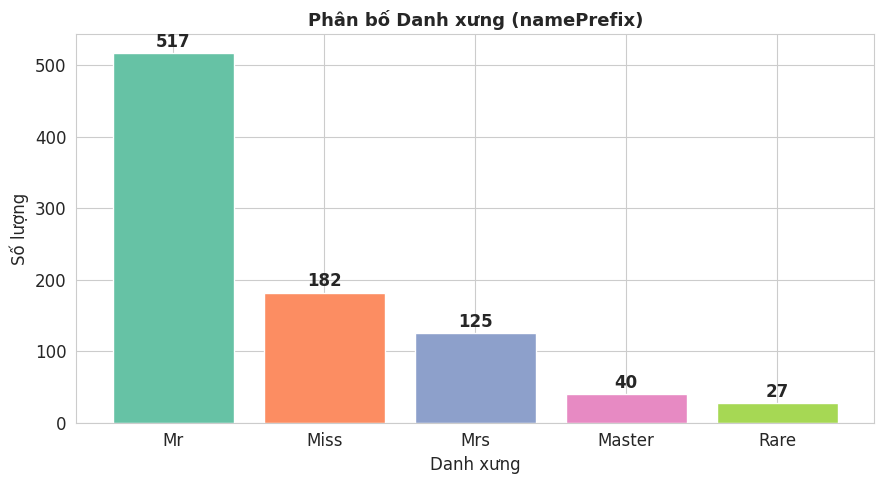

In [15]:
# Trực quan namePrefix
fig, ax = plt.subplots(figsize=(9, 5))
prefix_counts = df['namePrefix'].value_counts()
colors = sns.color_palette('Set2', len(prefix_counts))
bars = ax.bar(prefix_counts.index, prefix_counts.values, color=colors, edgecolor='white')
ax.set_title('Phân bố Danh xưng (namePrefix)', fontsize=13, fontweight='bold')
ax.set_xlabel('Danh xưng')
ax.set_ylabel('Số lượng')
for bar, val in zip(bars, prefix_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('nameprefix_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Bước 8: Tạo biến familySize

In [16]:
# ============================================================
# Bước 8: familySize = 1 + SibSp + Parch
# ============================================================

df['familySize'] = 1 + df['SibSp'] + df['Parch']

print(' Biến familySize đã được tạo:')
print(df['familySize'].value_counts().sort_index().to_string())
print(f'\n   Min: {df["familySize"].min()}  |  Max: {df["familySize"].max()}  |  Mean: {df["familySize"].mean():.2f}')

 Biến familySize đã được tạo:
familySize
1     537
2     161
3     102
4      29
5      15
6      22
7      12
8       6
11      7

   Min: 1  |  Max: 11  |  Mean: 1.90


## Bước 9: Tạo biến Alone

In [17]:
# ============================================================
# Bước 9: Alone = 1 nếu familySize == 1, ngược lại = 0
# ============================================================

df['Alone'] = (df['familySize'] == 1).astype(int)

print(' Biến Alone đã được tạo:')
alone_counts = df['Alone'].value_counts()
print(f"   Đi một mình (Alone=1)  : {alone_counts.get(1, 0)} hành khách ({alone_counts.get(1,0)/len(df)*100:.1f}%)")
print(f"   Đi theo nhóm (Alone=0) : {alone_counts.get(0, 0)} hành khách ({alone_counts.get(0,0)/len(df)*100:.1f}%)")

 Biến Alone đã được tạo:
   Đi một mình (Alone=1)  : 537 hành khách (60.3%)
   Đi theo nhóm (Alone=0) : 354 hành khách (39.7%)


## Bước 10: Trích xuất typeCabin

In [18]:
# ============================================================
# Bước 10: Tách loại Cabin (ký tự đầu tiên)
#          Nếu thiếu → 'Unknown'
# ============================================================

print('Ví dụ giá trị Cabin gốc:')
print(df['Cabin'].dropna().head(10).to_string())

df['typeCabin'] = df['Cabin'].apply(
    lambda x: x[0] if pd.notnull(x) else 'Unknown'
)

print('\n Phân bố typeCabin:')
print(df['typeCabin'].value_counts().to_string())

Ví dụ giá trị Cabin gốc:
1             C85
3            C123
6             E46
10             G6
11           C103
21            D56
23             A6
27    C23 C25 C27
31            B78
52            D33

 Phân bố typeCabin:
typeCabin
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1


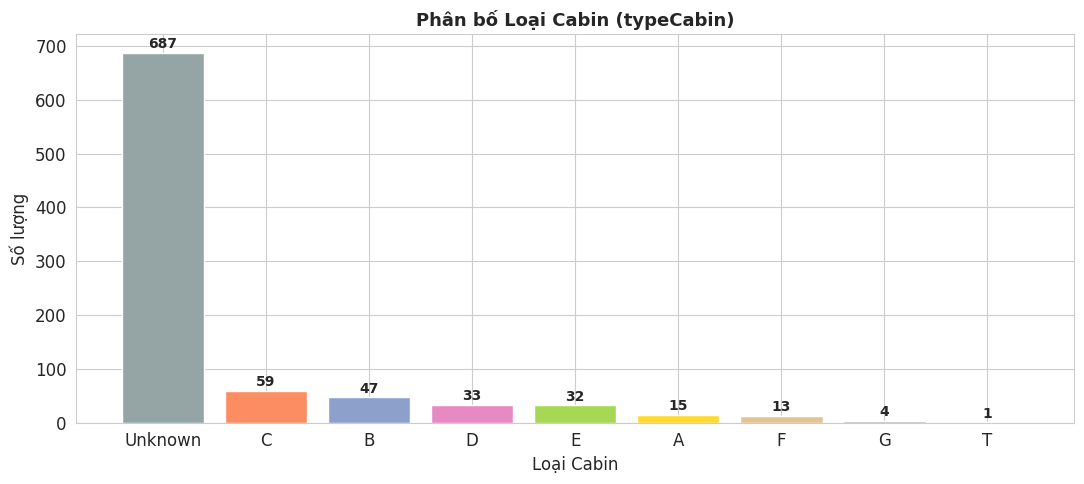

In [19]:
# Trực quan typeCabin
fig, ax = plt.subplots(figsize=(11, 5))
cabin_counts = df['typeCabin'].value_counts()
colors = ['#95a5a6' if c == 'Unknown' else sns.color_palette('Set1', 9)[i]
          for i, c in enumerate(cabin_counts.index) if c != 'Unknown']
colors = ['#95a5a6' if c == 'Unknown' else f'C{i}'
          for i, c in enumerate(cabin_counts.index)]
bars = ax.bar(cabin_counts.index, cabin_counts.values, color=colors, edgecolor='white')
ax.set_title('Phân bố Loại Cabin (typeCabin)', fontsize=13, fontweight='bold')
ax.set_xlabel('Loại Cabin')
ax.set_ylabel('Số lượng')
for bar, val in zip(bars, cabin_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 3,
            str(val), ha='center', va='bottom', fontsize=10, fontweight='bold')
plt.tight_layout()
plt.savefig('typecabin_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## Bước 11: Loại bỏ dữ liệu thừa & Kiểm tra dataset cuối

In [20]:
# ============================================================
# Bước 11: Loại bỏ dữ liệu trùng lặp
# (Trong bài này chỉ có 1 tập dữ liệu, kiểm tra duplicates)
# ============================================================

dupes_before = df.duplicated().sum()
print(f'Số hàng trùng lặp TRƯỚC xử lý: {dupes_before}')

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Số hàng trùng lặp SAU xử lý : {df.duplicated().sum()}')
print(f'\n Shape cuối cùng: {df.shape}')

# Tổng kết các cột
print('\n Các cột sau Feature Engineering:')
print(df.columns.tolist())

Số hàng trùng lặp TRƯỚC xử lý: 0
Số hàng trùng lặp SAU xử lý : 0

 Shape cuối cùng: (891, 18)

 Các cột sau Feature Engineering:
['PassengerId', 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'secondName', 'firstName', 'Agegroup', 'namePrefix', 'familySize', 'Alone', 'typeCabin']


In [21]:
# Xem dataset hoàn chỉnh
print(' 10 dòng đầu tiên sau toàn bộ quá trình xử lý:')
df.head(10)

 10 dòng đầu tiên sau toàn bộ quá trình xử lý:


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,secondName,firstName,Agegroup,namePrefix,familySize,Alone,typeCabin
0,1,0,3,M,22.0,1,0,A/5 21171,7.2500,NaN,S,Braund,Mr. Owen Harris,Adult,Mr,2,0,Unknown
1,2,1,1,F,38.0,1,0,PC 17599,71.2833,C85,C,Cumings,Mrs. John Bradley (Florence Briggs Thayer),Adult,Mrs,2,0,C
2,3,1,3,F,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Heikkinen,Miss. Laina,Adult,Miss,1,1,Unknown
3,4,1,1,F,35.0,1,0,113803,53.1000,C123,S,Futrelle,Mrs. Jacques Heath (Lily May Peel),Adult,Mrs,2,0,C
4,5,0,3,M,35.0,0,0,373450,8.0500,NaN,S,Allen,Mr. William Henry,Adult,Mr,1,1,Unknown
5,6,0,3,M,25.1,0,0,330877,8.4583,NaN,Q,Moran,Mr. James,Adult,Mr,1,1,Unknown
6,7,0,1,M,54.0,0,0,17463,51.8625,E46,S,McCarthy,Mr. Timothy J,Adult,Mr,1,1,E
7,8,0,3,M,2.0,3,1,349909,21.0750,NaN,S,Palsson,Master. Gosta Leonard,Kid,Master,5,0,Unknown
8,9,1,3,F,27.0,0,2,347742,11.1333,NaN,S,Johnson,Mrs. Oscar W (Elisabeth Vilhelmina Berg),Adult,Mrs,3,0,Unknown
9,10,1,2,F,14.0,1,0,237736,30.0708,NaN,C,Nasser,Mrs. Nicholas (Adele Achem),Teen,Mrs,2,0,Unknown


In [23]:
# Lưu dữ liệu đã xử lý
df.to_csv('titanic_processed.csv', index=False)
print(' Đã lưu dữ liệu đã xử lý vào file: titanic_processed.csv')

# Kiểm tra lần cuối dữ liệu thiếu
print('\n Kiểm tra dữ liệu thiếu cuối cùng:')
remaining_missing = df.isnull().sum()
print(remaining_missing[remaining_missing > 0].to_string() if remaining_missing.sum() > 0 else 'Không còn dữ liệu thiếu (trừ Cabin đã xử lý thành typeCabin)!')

 Đã lưu dữ liệu đã xử lý vào file: titanic_processed.csv

 Kiểm tra dữ liệu thiếu cuối cùng:
Cabin       687
Embarked      2


---
# PHẦN 2: KHAI THÁC THÔNG TIN HỮU ÍCH – EDA

>  Sau mỗi biểu đồ, sinh viên cần đưa ra nhận xét để rút trích thông tin có giá trị về hành khách sống sót.

## Câu 12: Tỉ lệ sống sót theo Giới tính

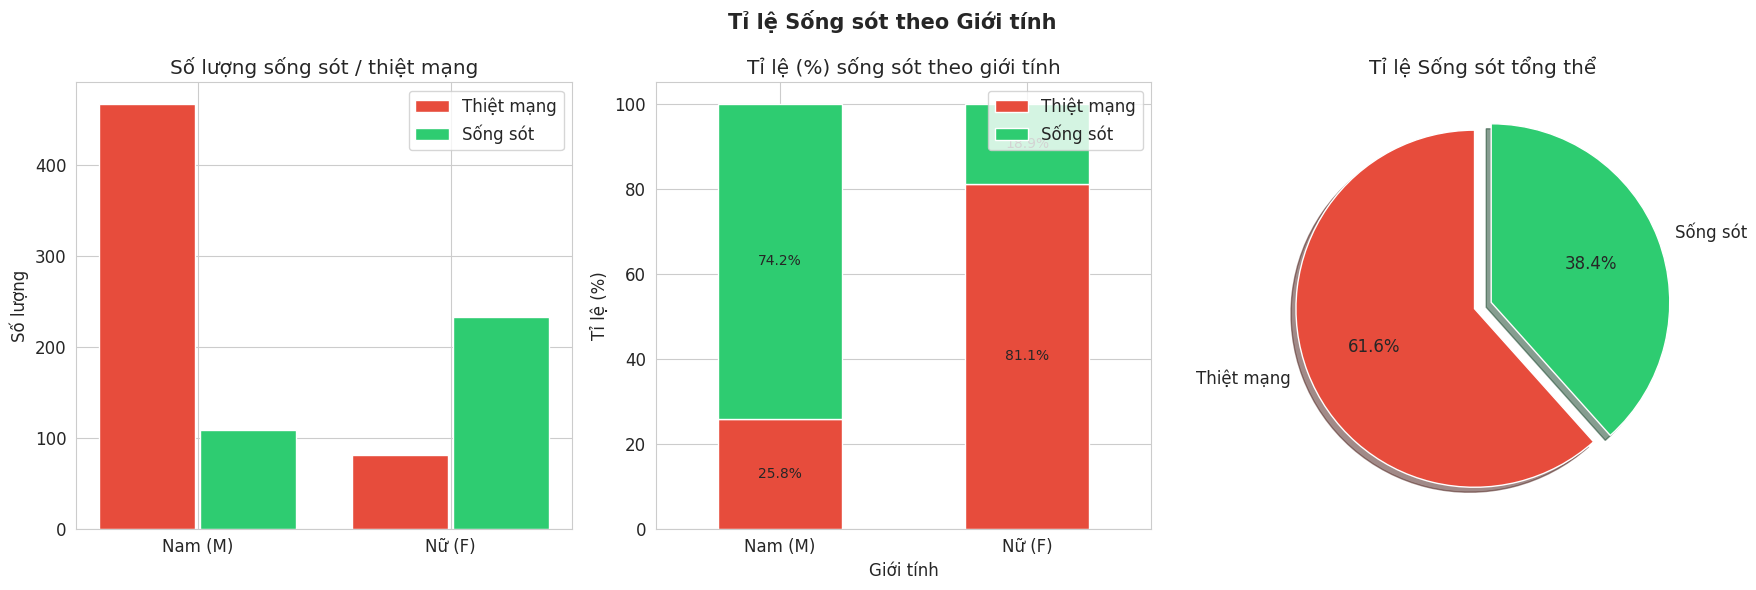

 Tỉ lệ sống sót theo giới tính:
Sex
F    74.2%
M    18.9%

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Nữ (F): Tỉ lệ sống sót ~74.2% – rất cao
• Nam (M): Tỉ lệ sống sót ~18.9% – rất thấp
→ Nguyên tắc "phụ nữ và trẻ em trước" được áp dụng rõ ràng.
→ Giới tính là đặc trưng quan trọng để dự đoán khả năng sống sót.



In [24]:
# ============================================================
# Câu 12: Trực quan tỉ lệ sống sót / thiệt mạng theo giới tính
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Tỉ lệ Sống sót theo Giới tính', fontsize=15, fontweight='bold')

# Màu sắc
survived_colors = {0: '#e74c3c', 1: '#2ecc71'}

# (1) Countplot
ax1 = axes[0]
survival_sex = df.groupby(['Sex', 'Survived']).size().reset_index(name='Count')
sex_order = ['M', 'F']
survived_labels = {0: 'Thiệt mạng', 1: 'Sống sót'}
for survived_val, group in survival_sex.groupby('Survived'):
    group_indexed = group.set_index('Sex')
    ax1.bar(
        [s + (0.2 if survived_val == 1 else -0.2) for s in range(len(sex_order))],
        [group_indexed.loc[s, 'Count'] if s in group_indexed.index else 0 for s in sex_order],
        width=0.38,
        label=survived_labels[survived_val],
        color=survived_colors[survived_val],
        edgecolor='white'
    )
ax1.set_xticks(range(len(sex_order)))
ax1.set_xticklabels(['Nam (M)', 'Nữ (F)'])
ax1.set_title('Số lượng sống sót / thiệt mạng')
ax1.set_ylabel('Số lượng')
ax1.legend()

# (2) Tỉ lệ % stacked bar
ax2 = axes[1]
surv_rate = df.groupby('Sex')['Survived'].value_counts(normalize=True).unstack()*100
surv_rate = surv_rate.rename(columns={0: 'Thiệt mạng', 1: 'Sống sót'})
surv_rate[['Thiệt mạng', 'Sống sót']].plot(
    kind='bar', stacked=True, ax=ax2,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='white'
)
ax2.set_title('Tỉ lệ (%) sống sót theo giới tính')
ax2.set_xlabel('Giới tính')
ax2.set_ylabel('Tỉ lệ (%)')
ax2.set_xticklabels(['Nam (M)', 'Nữ (F)'], rotation=0)
ax2.legend(loc='upper right')
for container in ax2.containers:
    ax2.bar_label(container, fmt='%.1f%%', label_type='center', fontsize=10)

# (3) Pie chart tổng tỉ lệ
ax3 = axes[2]
overall = df['Survived'].value_counts()
ax3.pie(
    overall.values,
    labels=['Thiệt mạng', 'Sống sót'],
    colors=['#e74c3c', '#2ecc71'],
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.05, 0.05),
    shadow=True
)
ax3.set_title('Tỉ lệ Sống sót tổng thể')

plt.tight_layout()
plt.savefig('survival_by_gender.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Tỉ lệ sống sót theo giới tính:')
print(df.groupby('Sex')['Survived'].mean().apply(lambda x: f'{x*100:.1f}%').to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Nữ (F): Tỉ lệ sống sót ~74.2% – rất cao
• Nam (M): Tỉ lệ sống sót ~18.9% – rất thấp
→ Nguyên tắc "phụ nữ và trẻ em trước" được áp dụng rõ ràng.
→ Giới tính là đặc trưng quan trọng để dự đoán khả năng sống sót.
""")

## Câu 13: Sống sót theo Pclass

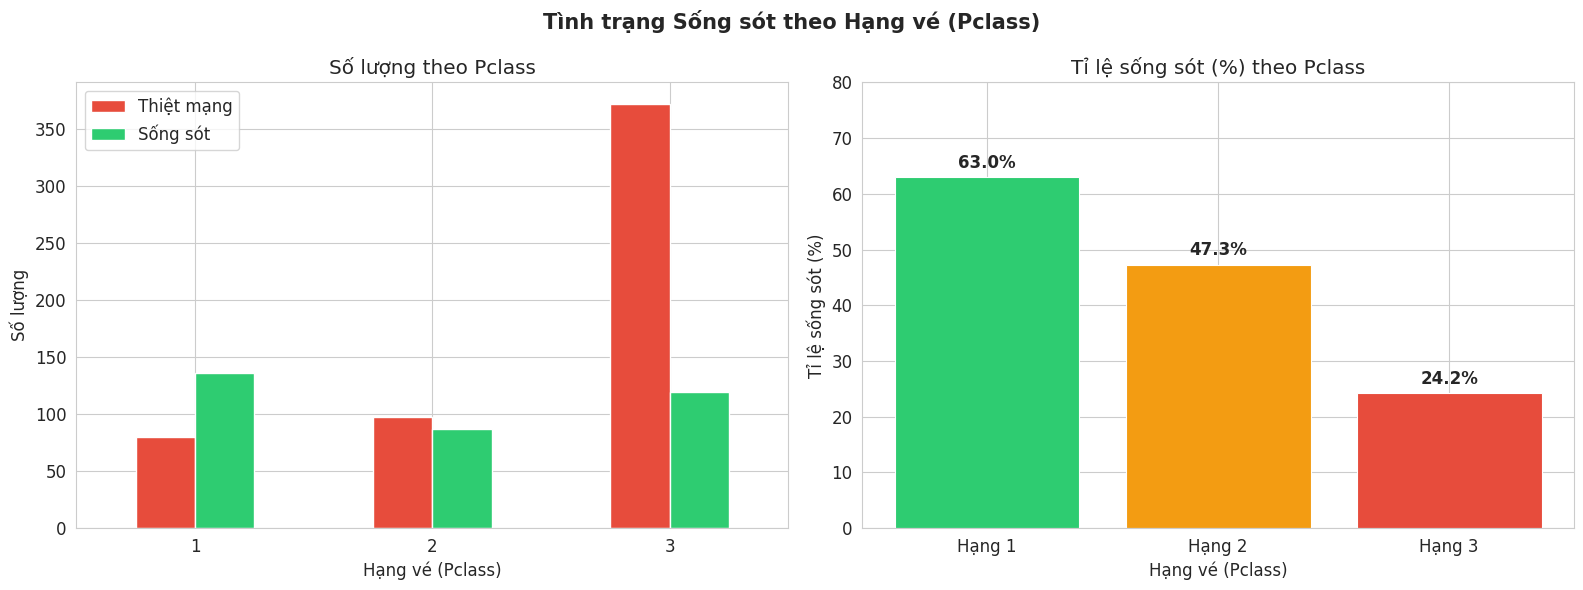

Tỉ lệ sống sót theo Pclass:
Pclass
1    63.0%
2    47.3%
3    24.2%

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Pclass 1 (hạng nhất): Tỉ lệ sống sót cao nhất (~63%) – ưu tiên tiếp cận xuồng cứu sinh
• Pclass 2 (hạng hai) : Tỉ lệ trung bình (~47%)
• Pclass 3 (hạng ba)  : Tỉ lệ thấp nhất (~24%) – điều kiện thoát hiểm khó khăn hơn
→ Địa vị kinh tế – xã hội có ảnh hưởng đáng kể đến khả năng sống sót.



In [25]:
# ============================================================
# Câu 13: Trực quan sống sót theo Pclass
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Tình trạng Sống sót theo Hạng vé (Pclass)', fontsize=15, fontweight='bold')

# (1) Grouped bar
ax1 = axes[0]
pclass_surv = df.groupby(['Pclass', 'Survived']).size().unstack(fill_value=0)
pclass_surv.columns = ['Thiệt mạng', 'Sống sót']
pclass_surv.plot(kind='bar', ax=ax1, color=['#e74c3c', '#2ecc71'],
                 edgecolor='white', rot=0)
ax1.set_title('Số lượng theo Pclass')
ax1.set_xlabel('Hạng vé (Pclass)')
ax1.set_ylabel('Số lượng')
ax1.legend()

# (2) Tỉ lệ sống sót
ax2 = axes[1]
surv_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100
bars = ax2.bar(surv_by_pclass.index, surv_by_pclass.values,
               color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='white', linewidth=0.8)
ax2.set_title('Tỉ lệ sống sót (%) theo Pclass')
ax2.set_xlabel('Hạng vé (Pclass)')
ax2.set_ylabel('Tỉ lệ sống sót (%)')
ax2.set_ylim(0, 80)
for bar, val in zip(bars, surv_by_pclass.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)
ax2.set_xticks([1, 2, 3])
ax2.set_xticklabels(['Hạng 1', 'Hạng 2', 'Hạng 3'])

plt.tight_layout()
plt.savefig('survival_by_pclass.png', dpi=150, bbox_inches='tight')
plt.show()

print('Tỉ lệ sống sót theo Pclass:')
print(surv_by_pclass.apply(lambda x: f'{x:.1f}%').to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Pclass 1 (hạng nhất): Tỉ lệ sống sót cao nhất (~63%) – ưu tiên tiếp cận xuồng cứu sinh
• Pclass 2 (hạng hai) : Tỉ lệ trung bình (~47%)
• Pclass 3 (hạng ba)  : Tỉ lệ thấp nhất (~24%) – điều kiện thoát hiểm khó khăn hơn
→ Địa vị kinh tế – xã hội có ảnh hưởng đáng kể đến khả năng sống sót.
""")

## Câu 14: Sống sót theo Giới tính & Nhóm tuổi

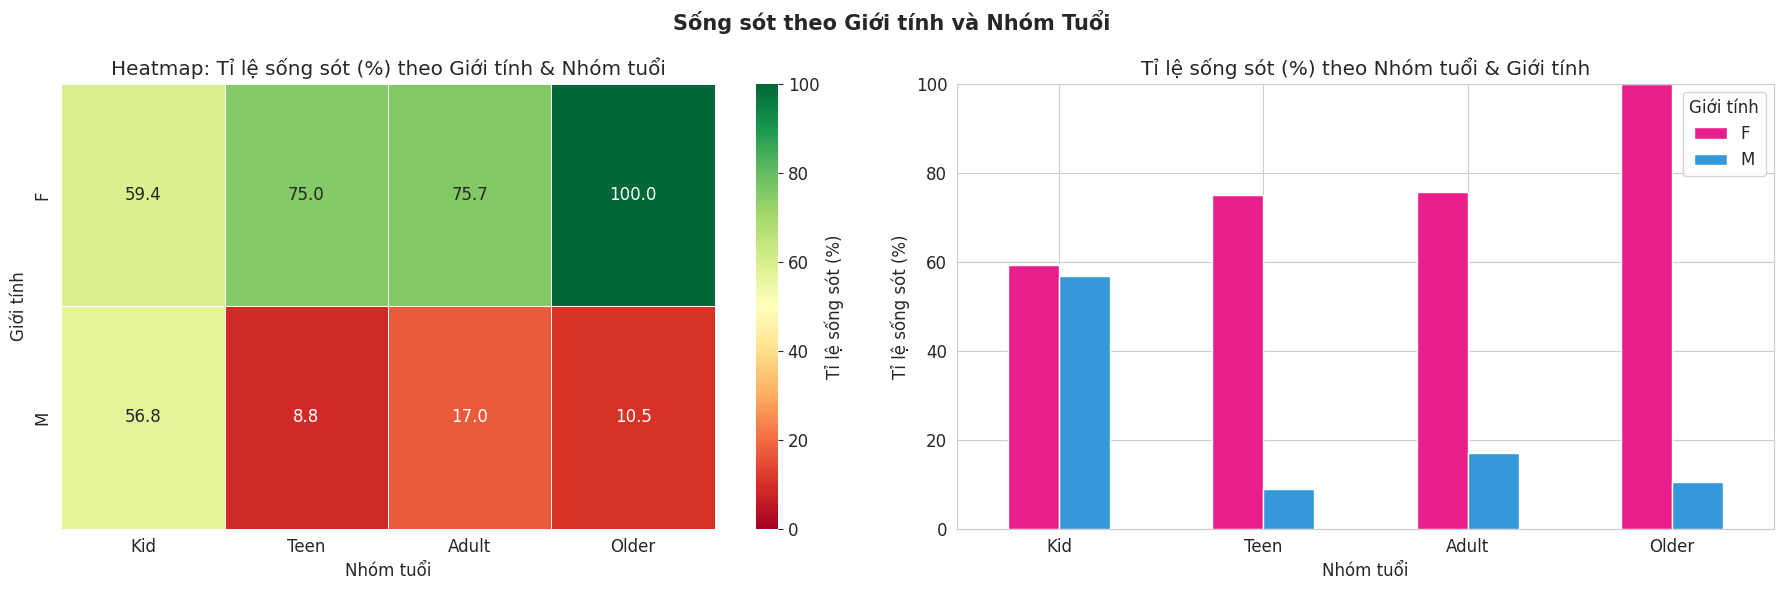

 Tỉ lệ sống sót (%) theo Giới tính & Nhóm tuổi:
Sex           F     M
Agegroup             
Kid        59.4  56.8
Teen       75.0   8.8
Adult      75.7  17.0
Older     100.0  10.5

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Nữ trong tất cả nhóm tuổi đều có tỉ lệ sống sót cao hơn Nam.
• Trẻ em (Kid) có tỉ lệ sống sót tương đối cao ở cả hai giới.
• Nam Older (>60 tuổi) có tỉ lệ sống sót thấp nhất.
→ Kết hợp giới tính + tuổi là bộ đặc trưng quan trọng trong mô hình dự đoán.



In [26]:
# ============================================================
# Câu 14: Trực quan sống sót theo giới tính và nhóm tuổi
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Sống sót theo Giới tính và Nhóm Tuổi', fontsize=15, fontweight='bold')

age_order = ['Kid', 'Teen', 'Adult', 'Older']

# (1) Heatmap tỉ lệ sống sót theo Sex × Agegroup
ax1 = axes[0]
pivot = df.pivot_table(values='Survived', index='Sex', columns='Agegroup', aggfunc='mean') * 100
pivot = pivot[age_order]
sns.heatmap(
    pivot, ax=ax1,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Tỉ lệ sống sót (%)'},
    vmin=0, vmax=100
)
ax1.set_title('Heatmap: Tỉ lệ sống sót (%) theo Giới tính & Nhóm tuổi')
ax1.set_xlabel('Nhóm tuổi')
ax1.set_ylabel('Giới tính')

# (2) Grouped bar
ax2 = axes[1]
surv_sex_age = df.groupby(['Agegroup', 'Sex'])['Survived'].mean().unstack() * 100
surv_sex_age = surv_sex_age.reindex(age_order)
surv_sex_age.plot(kind='bar', ax=ax2,
                  color={'M': '#3498db', 'F': '#e91e8c'},
                  edgecolor='white', rot=0)
ax2.set_title('Tỉ lệ sống sót (%) theo Nhóm tuổi & Giới tính')
ax2.set_xlabel('Nhóm tuổi')
ax2.set_ylabel('Tỉ lệ sống sót (%)')
ax2.legend(title='Giới tính')
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.savefig('survival_gender_agegroup.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Tỉ lệ sống sót (%) theo Giới tính & Nhóm tuổi:')
print(surv_sex_age.round(1).to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Nữ trong tất cả nhóm tuổi đều có tỉ lệ sống sót cao hơn Nam.
• Trẻ em (Kid) có tỉ lệ sống sót tương đối cao ở cả hai giới.
• Nam Older (>60 tuổi) có tỉ lệ sống sót thấp nhất.
→ Kết hợp giới tính + tuổi là bộ đặc trưng quan trọng trong mô hình dự đoán.
""")

## Câu 15: Xác suất sống sót theo nhóm đi cùng (familySize)

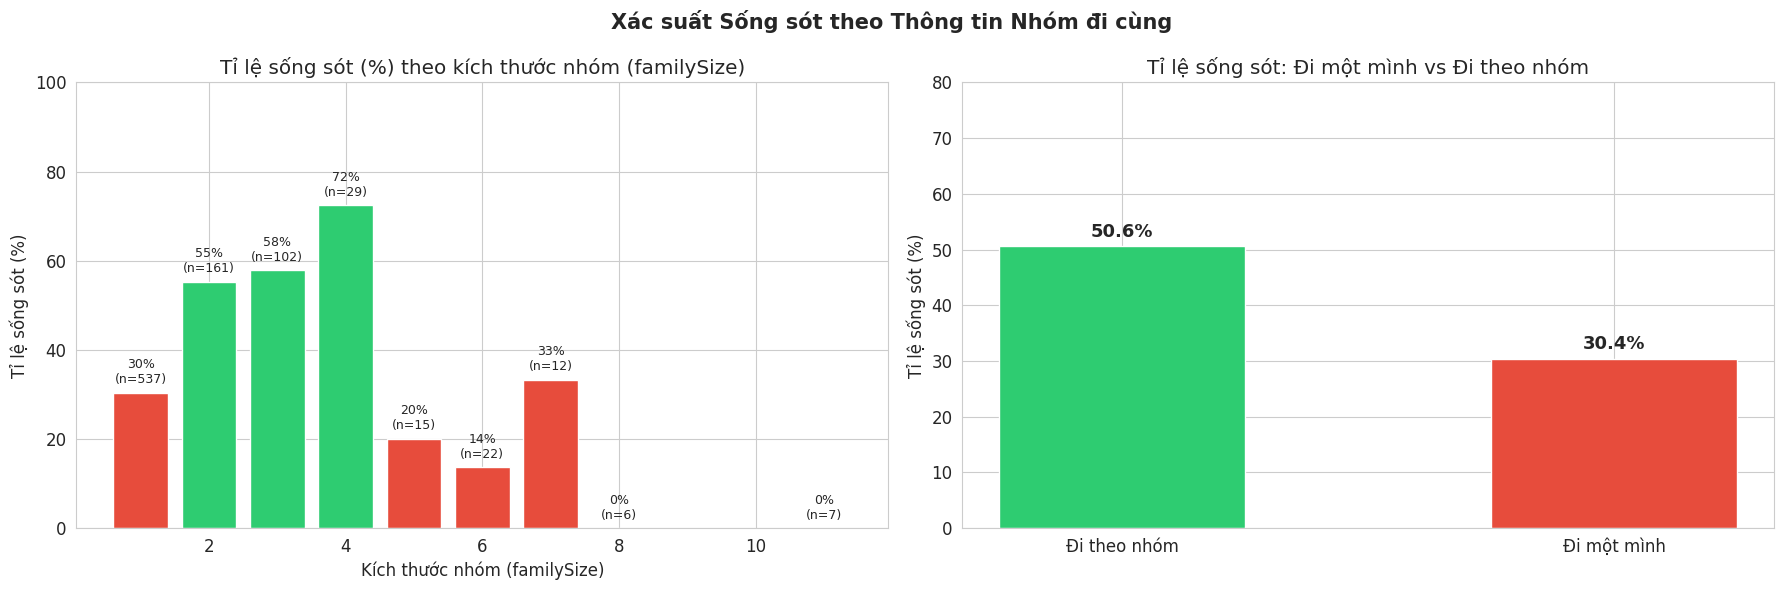

 Tỉ lệ sống sót theo Alone (0=nhóm, 1=một mình):
Alone
0    50.6%
1    30.4%

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Hành khách đi theo nhóm nhỏ (2-4 người) có tỉ lệ sống sót cao nhất.
• Hành khách đi một mình hoặc nhóm quá lớn (≥5) có tỉ lệ sống sót thấp hơn.
• Đi một mình: ~30.4% | Đi theo nhóm: ~50.6%
→ Kích thước nhóm gia đình ảnh hưởng đến khả năng thoát thân.



In [27]:
# ============================================================
# Câu 15: Xác suất sống sót theo thông tin nhóm đi cùng
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Xác suất Sống sót theo Thông tin Nhóm đi cùng', fontsize=15, fontweight='bold')

# (1) FamilySize
ax1 = axes[0]
surv_family = df.groupby('familySize')['Survived'].mean() * 100
count_family = df.groupby('familySize').size()
colors = ['#e74c3c' if v < 40 else '#2ecc71' for v in surv_family.values]
bars = ax1.bar(surv_family.index, surv_family.values, color=colors, edgecolor='white')
ax1.set_title('Tỉ lệ sống sót (%) theo kích thước nhóm (familySize)')
ax1.set_xlabel('Kích thước nhóm (familySize)')
ax1.set_ylabel('Tỉ lệ sống sót (%)')
ax1.set_ylim(0, 100)
for bar, val, cnt in zip(bars, surv_family.values, count_family.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1.5,
             f'{val:.0f}%\n(n={cnt})', ha='center', va='bottom', fontsize=9)

# (2) Alone vs Group
ax2 = axes[1]
surv_alone = df.groupby('Alone')['Survived'].mean() * 100
labels = ['Đi theo nhóm', 'Đi một mình']
bars2 = ax2.bar(labels, surv_alone.values,
                color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
ax2.set_title('Tỉ lệ sống sót: Đi một mình vs Đi theo nhóm')
ax2.set_ylabel('Tỉ lệ sống sót (%)')
ax2.set_ylim(0, 80)
for bar, val in zip(bars2, surv_alone.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('survival_family.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Tỉ lệ sống sót theo Alone (0=nhóm, 1=một mình):')
print(surv_alone.apply(lambda x: f'{x:.1f}%').to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Hành khách đi theo nhóm nhỏ (2-4 người) có tỉ lệ sống sót cao nhất.
• Hành khách đi một mình hoặc nhóm quá lớn (≥5) có tỉ lệ sống sót thấp hơn.
• Đi một mình: ~30.4% | Đi theo nhóm: ~50.6%
→ Kích thước nhóm gia đình ảnh hưởng đến khả năng thoát thân.
""")

## Câu 16: Xác suất sống sót theo giá vé (Fare)

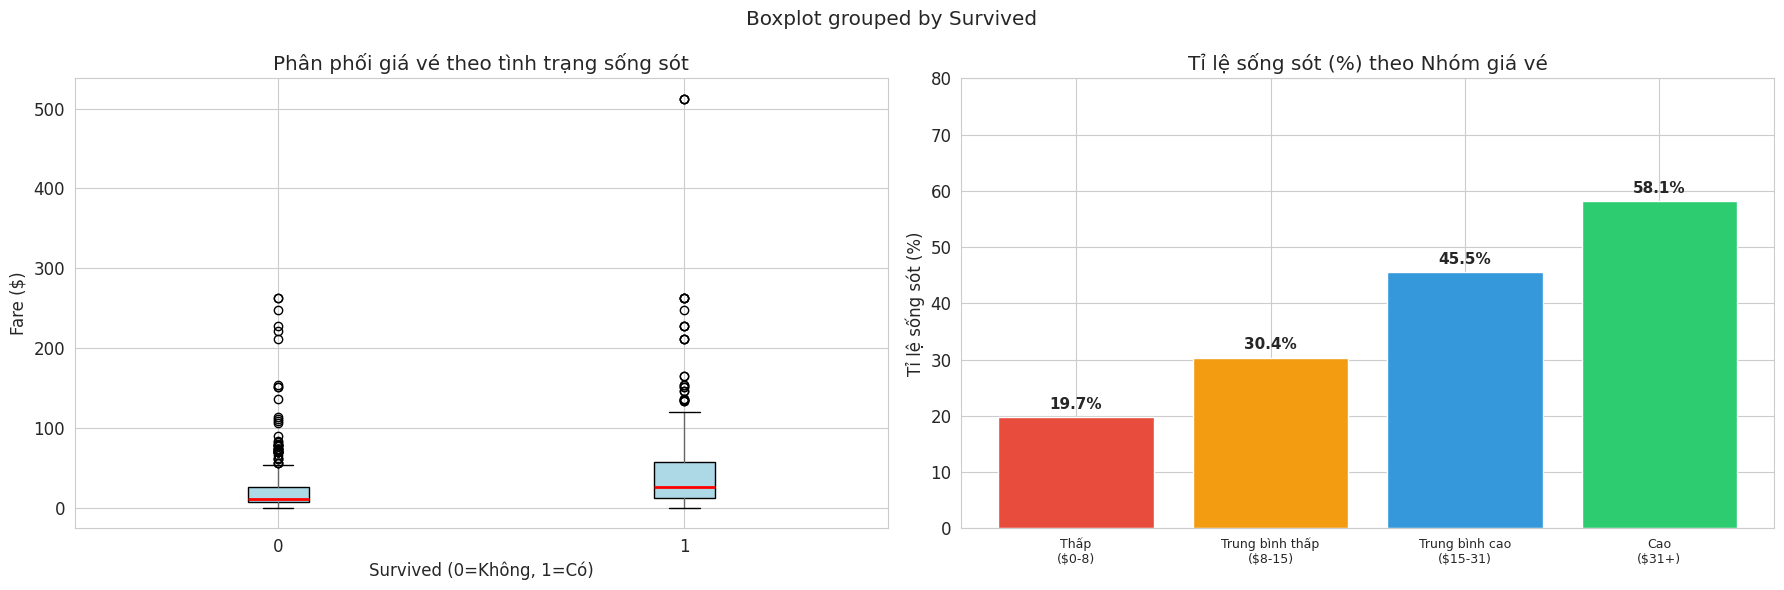

 Tỉ lệ sống sót theo nhóm giá vé:
FareBand
Thấp\n($0-8)                19.7%
Trung bình thấp\n($8-15)    30.4%
Trung bình cao\n($15-31)    45.5%
Cao\n($31+)                 58.1%

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Hành khách mua vé cao hơn có tỉ lệ sống sót cao hơn rõ rệt.
• Nhóm vé rẻ nhất ($0-8): tỉ lệ sống sót thấp (~17-20%).
• Nhóm vé đắt nhất ($31+): tỉ lệ sống sót cao nhất (~60%).
→ Giá vé phản ánh gián tiếp Pclass – ảnh hưởng đến vị trí phòng và tiếp cận xuồng cứu sinh.



In [28]:
# ============================================================
# Câu 16: Trực quan xác suất sống sót theo giá vé (Fare)
# ============================================================

# Tạo nhóm giá vé
df['FareBand'] = pd.qcut(df['Fare'], q=4,
                          labels=['Thấp\n($0-8)', 'Trung bình thấp\n($8-15)',
                                  'Trung bình cao\n($15-31)', 'Cao\n($31+)'])

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Xác suất Sống sót theo Giá Vé (Fare)', fontsize=15, fontweight='bold')

# (1) Boxplot Fare vs Survived
ax1 = axes[0]
df.boxplot(column='Fare', by='Survived', ax=ax1,
           patch_artist=True,
           boxprops=dict(facecolor='lightblue'),
           medianprops=dict(color='red', linewidth=2))
ax1.set_title('Phân phối giá vé theo tình trạng sống sót')
ax1.set_xlabel('Survived (0=Không, 1=Có)')
ax1.set_ylabel('Fare ($)')
plt.sca(ax1)
plt.title('Phân phối giá vé theo tình trạng sống sót')

# (2) Tỉ lệ sống sót theo FareBand
ax2 = axes[1]
surv_fare = df.groupby('FareBand', observed=True)['Survived'].mean() * 100
colors_fare = ['#e74c3c', '#f39c12', '#3498db', '#2ecc71']
bars = ax2.bar(range(len(surv_fare)), surv_fare.values,
               color=colors_fare, edgecolor='white')
ax2.set_xticks(range(len(surv_fare)))
ax2.set_xticklabels(surv_fare.index, fontsize=9)
ax2.set_title('Tỉ lệ sống sót (%) theo Nhóm giá vé')
ax2.set_ylabel('Tỉ lệ sống sót (%)')
ax2.set_ylim(0, 80)
for bar, val in zip(bars, surv_fare.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('survival_fare.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Tỉ lệ sống sót theo nhóm giá vé:')
print(surv_fare.apply(lambda x: f'{x:.1f}%').to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Hành khách mua vé cao hơn có tỉ lệ sống sót cao hơn rõ rệt.
• Nhóm vé rẻ nhất ($0-8): tỉ lệ sống sót thấp (~17-20%).
• Nhóm vé đắt nhất ($31+): tỉ lệ sống sót cao nhất (~60%).
→ Giá vé phản ánh gián tiếp Pclass – ảnh hưởng đến vị trí phòng và tiếp cận xuồng cứu sinh.
""")

## Câu 17: Sống sót theo Pclass & Cảng xuất phát (Embarked)

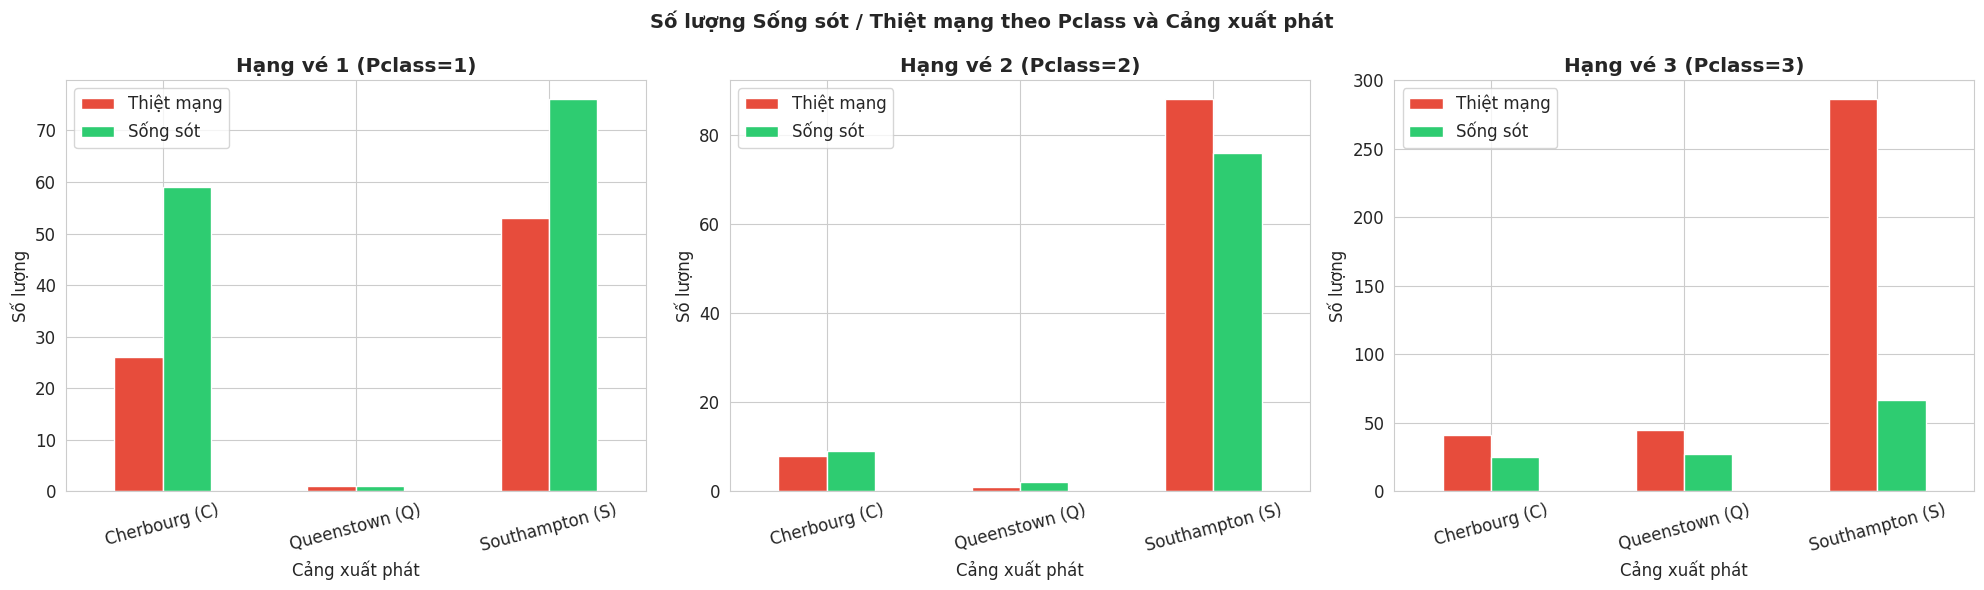

In [29]:
# ============================================================
# Câu 17: Trực quan số lượng thiệt mạng/sống sót
#         theo Pclass và cảng xuất phát (Embarked)
# ============================================================

# Xử lý Embarked còn thiếu (2 giá trị)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

embarked_labels = {'C': 'Cherbourg (C)', 'Q': 'Queenstown (Q)', 'S': 'Southampton (S)'}
df['EmbarkedLabel'] = df['Embarked'].map(embarked_labels)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Số lượng Sống sót / Thiệt mạng theo Pclass và Cảng xuất phát',
             fontsize=14, fontweight='bold')

colors_surv = {0: '#e74c3c', 1: '#2ecc71'}
pclass_colors = {1: '#1a252f', 2: '#2c3e50', 3: '#5d6d7e'}

for idx, (pclass, ax) in enumerate(zip([1, 2, 3], axes)):
    pclass_data = df[df['Pclass'] == pclass]

    pivot_data = pclass_data.groupby(['EmbarkedLabel', 'Survived']).size().unstack(fill_value=0)
    pivot_data.columns = ['Thiệt mạng', 'Sống sót']

    pivot_data.plot(
        kind='bar', ax=ax,
        color=['#e74c3c', '#2ecc71'],
        edgecolor='white', rot=15
    )
    ax.set_title(f'Hạng vé {pclass} (Pclass={pclass})', fontweight='bold')
    ax.set_xlabel('Cảng xuất phát')
    ax.set_ylabel('Số lượng')
    ax.legend()

plt.tight_layout()
plt.savefig('survival_pclass_embarked.png', dpi=150, bbox_inches='tight')
plt.show()

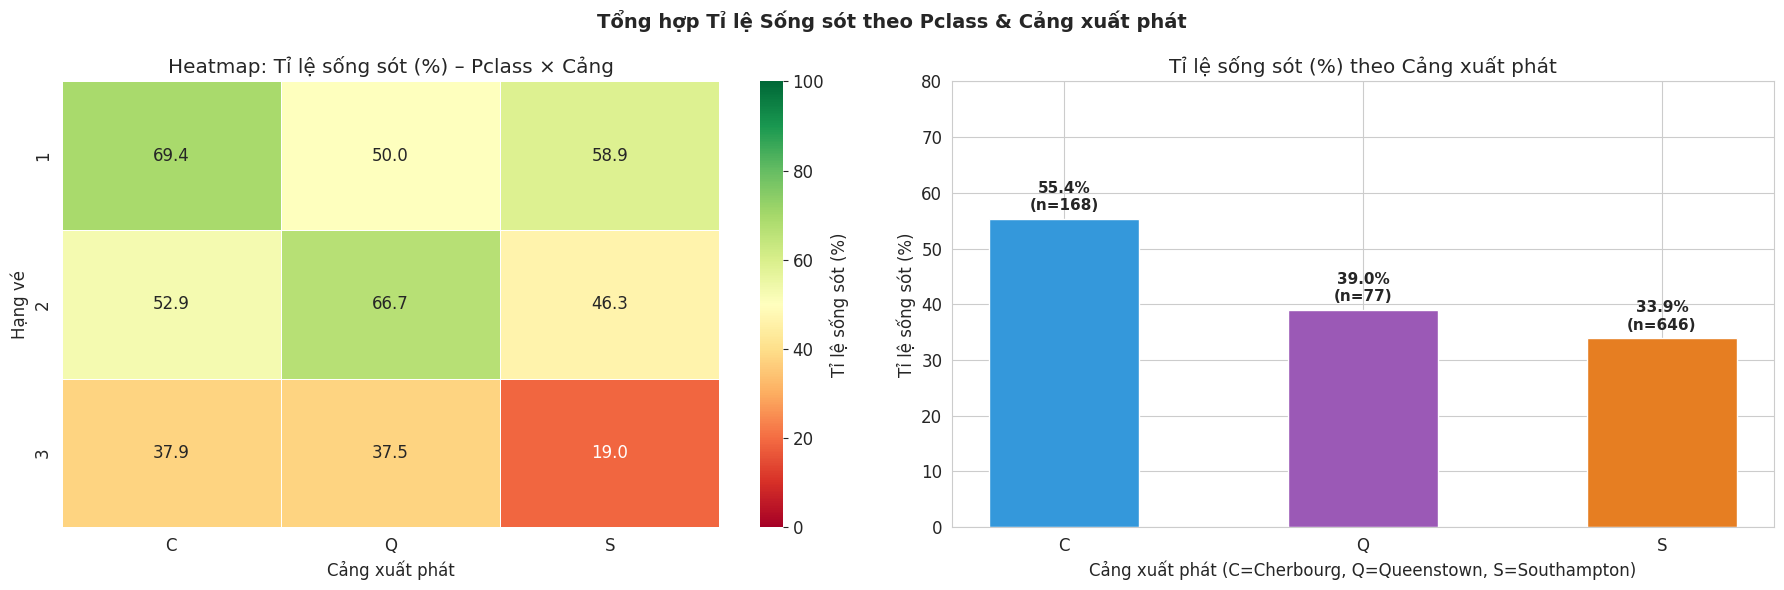

 Tỉ lệ sống sót theo cảng xuất phát:
Embarked
C    55.4%
Q    39.0%
S    33.9%

 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Cảng Cherbourg (C): Tỉ lệ sống sót cao nhất (~55.4%) – nhiều hành khách hạng 1
• Cảng Queenstown (Q): Tỉ lệ trung bình (~38.9%)
• Cảng Southampton (S): Tỉ lệ thấp nhất (~33.7%) – đông hành khách hạng 3 nhất
→ Sự khác biệt cảng xuất phát liên quan đến cơ cấu hành khách theo Pclass.
→ Hành khách Pclass 1 lên tàu nhiều hơn ở Cherbourg → tỉ lệ sống sót cao hơn.



In [30]:
# Tổng hợp tỉ lệ sống sót theo Pclass × Embarked
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Tổng hợp Tỉ lệ Sống sót theo Pclass & Cảng xuất phát', fontsize=14, fontweight='bold')

# Heatmap
ax1 = axes[0]
pivot_heatmap = df.pivot_table(values='Survived', index='Pclass',
                                columns='Embarked', aggfunc='mean') * 100
sns.heatmap(
    pivot_heatmap, ax=ax1,
    annot=True, fmt='.1f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': 'Tỉ lệ sống sót (%)'},
    vmin=0, vmax=100
)
ax1.set_title('Heatmap: Tỉ lệ sống sót (%) – Pclass × Cảng')
ax1.set_xlabel('Cảng xuất phát')
ax1.set_ylabel('Hạng vé')

# Tổng thể theo Embarked
ax2 = axes[1]
surv_embarked = df.groupby('Embarked')['Survived'].mean() * 100
count_embarked = df.groupby('Embarked').size()
bars = ax2.bar(surv_embarked.index, surv_embarked.values,
               color=['#3498db', '#9b59b6', '#e67e22'],
               edgecolor='white', width=0.5)
ax2.set_title('Tỉ lệ sống sót (%) theo Cảng xuất phát')
ax2.set_xlabel('Cảng xuất phát (C=Cherbourg, Q=Queenstown, S=Southampton)')
ax2.set_ylabel('Tỉ lệ sống sót (%)')
ax2.set_ylim(0, 80)
for bar, val, cnt in zip(bars, surv_embarked.values, count_embarked.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.1f}%\n(n={cnt})', ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('survival_embarked_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print(' Tỉ lệ sống sót theo cảng xuất phát:')
print(surv_embarked.apply(lambda x: f'{x:.1f}%').to_string())
print("""
 NHẬN XÉT:
─────────────────────────────────────────────────────────────
• Cảng Cherbourg (C): Tỉ lệ sống sót cao nhất (~55.4%) – nhiều hành khách hạng 1
• Cảng Queenstown (Q): Tỉ lệ trung bình (~38.9%)
• Cảng Southampton (S): Tỉ lệ thấp nhất (~33.7%) – đông hành khách hạng 3 nhất
→ Sự khác biệt cảng xuất phát liên quan đến cơ cấu hành khách theo Pclass.
→ Hành khách Pclass 1 lên tàu nhiều hơn ở Cherbourg → tỉ lệ sống sót cao hơn.
""")

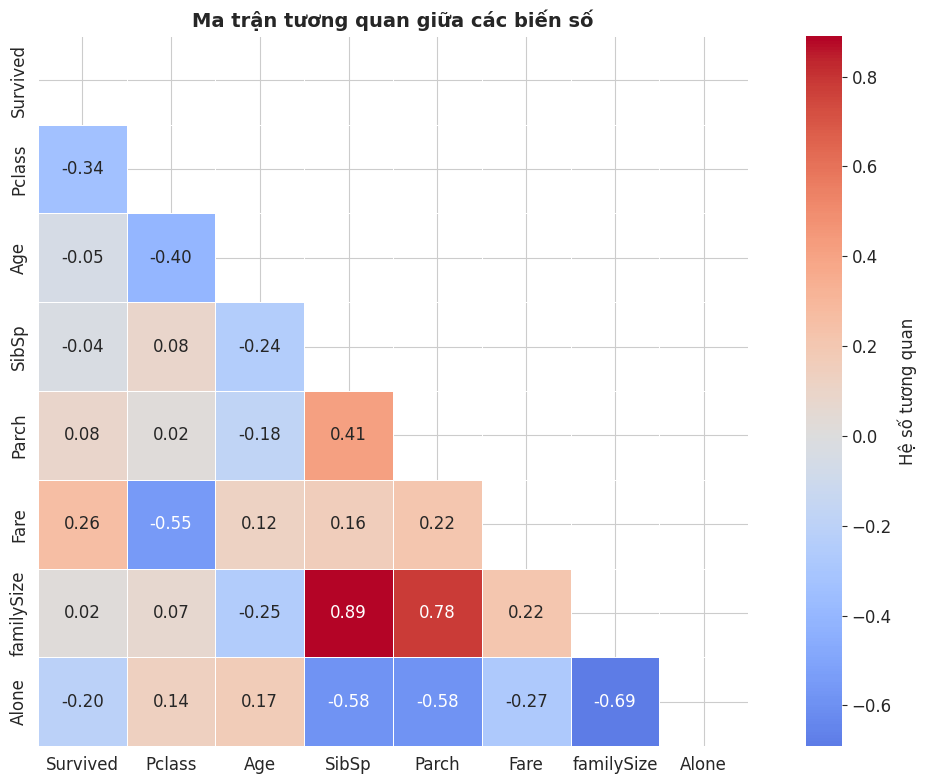


 NHẬN XÉT Ma trận tương quan:
   • Survived – Fare     : tương quan dương (vé đắt → sống sót nhiều hơn)
   • Survived – Pclass   : tương quan âm (hạng cao=1 → sống sót nhiều hơn)
   • Survived – Alone    : tương quan âm (đi một mình → khó sống sót hơn)
   • Pclass – Fare       : tương quan âm mạnh (hạng 1 trả nhiều hơn)


In [32]:
# Correlation heatmap tổng quát
fig, ax = plt.subplots(figsize=(12, 8))

numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'familySize', 'Alone']
corr_matrix = df[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    ax=ax,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    mask=mask,
    cbar_kws={'label': 'Hệ số tương quan'}
)
ax.set_title('Ma trận tương quan giữa các biến số', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n NHẬN XÉT Ma trận tương quan:')
print('   • Survived – Fare     : tương quan dương (vé đắt → sống sót nhiều hơn)')
print('   • Survived – Pclass   : tương quan âm (hạng cao=1 → sống sót nhiều hơn)')
print('   • Survived – Alone    : tương quan âm (đi một mình → khó sống sót hơn)')
print('   • Pclass – Fare       : tương quan âm mạnh (hạng 1 trả nhiều hơn)')